# Day 001 · 课程总览：365天能学到什么 · 中国版
**365-Day Roadmap** · 阶段 P1 · 量化基础

> 这是一节定调课。我们会把 365 天压缩到 25 分钟,让你看清整个量化金融的版图。看完之后你会明白三件事:量化到底是什么、散户做量化能不能赚钱、自己要不要走这条路。这不是一节赚钱课,这是一节决定要不要赚钱的课。

---

### 关于「中国版」

本 notebook 是为**国内学员**优化的版本:
- 数据源用 **akshare**(国内可访问、零 VPN、免注册),取代了视频里的 yfinance
- 标的尽量保持原意:美股 ETF→A 股 ETF / 国际公司→A 股龙头
- 所讲的**概念和方法 100% 一致**,但**具体数字可能与视频里略有差异**(因为是不同时间窗 / 不同标的)
- 一般情况国内 `pip install akshare` 即可,无需 token / VPN

**课件生成日期:** 2026-05-04  ·  **建议学习时长:** 18 分钟

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有必需的 Python 包(含 `akshare`),缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续


In [6]:
# === 环境自检 + 自动安装(运行此单元格即可)===
import importlib, subprocess, sys, os

REQUIRED = ["akshare", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels"]
PIP_NAME = {"sklearn":"scikit-learn","cv2":"opencv-python","PIL":"Pillow","bs4":"beautifulsoup4","yaml":"PyYAML"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))
if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置 ===
import matplotlib, matplotlib.pyplot as plt, matplotlib.font_manager as fm
CJK = ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
       "C:/Windows/Fonts/msyh.ttc","C:/Windows/Fonts/simhei.ttf",
       "/System/Library/Fonts/PingFang.ttc","/System/Library/Fonts/STHeiti Medium.ttc"]
for p in CJK:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP","Microsoft YaHei","PingFang SC","SimHei","DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪


## 🔌 第二步:加载国内数据助手

下面这一格是**工具函数**(可以折叠,不需要修改)。它把 `yfinance` 风格的 ticker(如 `600519.SS`)自动路由到对应的 akshare 接口,提供 `get_close(ticker)` 和 `get_close_multi(tickers_dict)` 两个函数。

In [7]:
# === 国内数据源助手(akshare 后端,不需要 VPN)===
# 这一格是工具函数,可以折叠,不需要修改。
# 它把 yfinance 风格的 ticker(如 "600519.SS" / "0700.HK" / "AAPL" / "BTC-USD")
# 自动路由到对应的 akshare 接口,统一返回 yfinance 风格的 Close DataFrame。

import re
from datetime import datetime, timedelta
import pandas as pd
import akshare as ak

_TICKER_MAP = {
    "^GSPC": ("us_index_sina", ".INX"),
    "^DJI":  ("us_index_sina", ".DJI"),
    "^IXIC": ("us_index_sina", ".IXIC"),
    "GC=F":  ("foreign_futures", "GC"),
    "SI=F":  ("foreign_futures", "SI"),
    "CL=F":  ("foreign_futures", "CL"),
    "BTC-USD": ("crypto", "BTC"),
    "ETH-USD": ("crypto", "ETH"),
}

def _parse_period(period):
    end = datetime.today()
    m = re.match(r"^(\d+)\s*(y|mo|d|w)$", period.lower().strip())
    days = 365 * 3 if not m else int(m.group(1)) * {"y":365,"mo":30,"w":7,"d":1}[m.group(2)]
    return (end - timedelta(days=days+30)).strftime("%Y%m%d"), end.strftime("%Y%m%d")

def _classify(ticker):
    t = ticker.strip()
    if t in _TICKER_MAP: return _TICKER_MAP[t]
    if t.endswith((".SS",".SH",".SZ")):
        code = t.split(".")[0]
        if code.startswith(("51","159","58")) or code in ("510300","510500","510050","511010","513100"):
            return ("a_etf", code)
        if code in ("000300","000016","000905","000852","000001"):
            return ("a_index", code)
        return ("a_stock", code)
    if t.endswith(".HK"):
        return ("hk", t.split(".")[0].zfill(5))
    return ("us", t)

def _norm(df, dc, cc):
    out = df[[dc, cc]].copy()
    out[dc] = pd.to_datetime(out[dc])
    return out.set_index(dc).sort_index()[cc].astype(float).rename("Close")

def get_close(ticker, period="3y"):
    """返回某标的 Close 价格 series。后端 akshare,中国可访问。"""
    start, end = _parse_period(period)
    kind, sym = _classify(ticker)
    if kind == "a_stock":
        return _norm(ak.stock_zh_a_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_etf":
        return _norm(ak.fund_etf_hist_em(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_index":
        idx_map = {"000300":"sh000300","000016":"sh000016","000905":"sh000905","000852":"sh000852","000001":"sh000001"}
        s = _norm(ak.stock_zh_index_daily_em(symbol=idx_map.get(sym, f"sh{sym}")), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "hk":
        return _norm(ak.stock_hk_hist(symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "us":
        # 美股走新浪源(stock_us_daily 直接吃 NVDA / AAPL 裸 symbol;stock_us_hist 要带前缀)
        s = _norm(ak.stock_us_daily(symbol=sym, adjust="qfq"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "us_index_sina":
        s = _norm(ak.index_us_stock_sina(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "foreign_futures":
        s = _norm(ak.futures_foreign_hist(symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "crypto":
        s = _norm(ak.crypto_hist(symbol=sym, period="daily"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    raise ValueError(f"unsupported ticker: {ticker}")

def get_close_multi(tickers, period="3y"):
    """批量取 Close,返回 DataFrame,列名是 tickers dict 的 key(中文名),按交集日期对齐。"""
    series = {name: get_close(t, period=period) for name, t in tickers.items()}
    return pd.concat(series, axis=1).sort_index()

print("✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据")


✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据


## 学习目标

- 搞清楚量化金融的边界:它能解决什么、解决不了什么
- 看懂这 365 天的整体地图,知道每个阶段你会进化成什么样
- 评估自己的起点(代码、数学、资金、时间),给自己定一个现实的节奏
- 建立量化思维的第一块砖:用概率和规则代替直觉
- 了解一名散户做量化的真实成本(钱、时间、心力)

## 历史背景:量化简史:从 IBM 大型机到你的笔记本

1971 年,Ed Thorp 用一本叫《Beat the Dealer》的书把概率论从赌场带进华尔街。1982 年 Renaissance Technologies(文艺复兴)成立,数学家 James Simons 用纯数学模型把它的旗舰基金 Medallion 做成了几十年年化 35% 后的传奇。1990 年代起 LTCM 让世界看到量化的极致与脆弱。2010 年之后,中国 A 股迎来私募量化的爆发,九坤、明汯、幻方、衍复一路把规模卷到千亿级。

而真正属于散户的窗口出现在 2018 年之后:Tushare/akshare 提供免费数据,Python 量化生态(pandas/Backtrader/vnpy)成熟,云服务器一个月几十块,加密交易所开放免费 API。今天一个本科生能在自己电脑上做的事,十年前一个机构需要一支团队。这个窗口不会永远开着,但现在它是开的。

**关键人物:**
- Ed Thorp(量化交易之父)
- James Simons(Medallion 35% 神话)
- John Meriwether(LTCM 创始人)

## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 量化金融的三层定义

数据 + 模型 + 工程,缺一不可。

数据层:能拿到的、干净的、时间对齐的、不含未来信息的数据。这是量化的原料,90% 的散户死在这里。
模型层:把假设转化为可计算的规则。常见有因子模型、时间序列模型、机器学习模型。模型 ≠ 复杂,简单模型常常胜过复杂模型。
工程层:让你的策略每天 9:30 自动跑、出错时自动报警、回测和实盘行为一致。这是量化区别于'用 Excel 选股'的本质。

```
Quant = (Data × Model × Engineering) ^ Discipline
```

> **举例:** 买在过去一个月涨得多的前 20 只股票 = 量化思维的最简版本。简单,但每个环节都是数据/模型/工程的体现。


### 2. 散户量化能做什么、不能做什么

能做的:中低频(日线/分钟)、容量小的策略,比如多因子选股、CTA 趋势、期权波动率交易、加密 funding 套利、可转债打新等。这些策略对延迟要求低,对资金量不敏感,在小资金上反而比大机构更灵活。

不能做的:高频做市、闪电套利、需要 co-location 和专线的策略。这些是机构军备竞赛的战场,散户进去就是给机构送学费。

散户的真正优势:容量灵活、决策链短、情绪自控好。劣势:数据贵、算力小、研究孤独。

> **举例:** 实操推荐:小资金(<20万)做月度多因子选股 + 小笔可转债打新。中等资金(20-200万)可以加 CTA + 期权 covered call。


### 3. 365 天怎么用:11 阶段学习路径

P1 量化基础(D1-30):金融、统计、Python 入门三件套
P2 Python 工具栈(D31-60):pandas/numpy/可视化深练
P3 数据与因子(D61-90):干净数据、因子库、中性化
P4 经典策略(D91-130):双均线/海龟/配对/PEAD/CTA 等 40 个策略
P5 回测稳健性(D131-160):未来函数/过拟合/walk-forward
P6 ML + 量化(D161-200):XGBoost/LSTM/RL/NLP/LLM
P7 衍生品 + 加密(D201-240):期货/期权/funding
P8 风险与组合(D241-280):VaR/Kelly/Risk Parity/cvxpy
P9 HFT 与微结构(D281-310):理解机构,不一定做
P10 实盘工程化(D311-340):CTP/IB/Binance API
P11 前沿与项目(D341-365):LLM/因果/5 大 Capstone

> **举例:** 用今天 25 分钟,看完整个地图,然后选出 3 个你最感兴趣的阶段,作为 365 天的'高光锚点'。


### 4. 工具栈和成本一览

免费的:Python + Anaconda(0元)、VS Code(0元)、yfinance/akshare(0元)、Backtrader(0元)、GitHub(0元)。这套足够你做完 P1-P5。

小钱的:Tushare 高级版(每年 200-500 元)、云服务器(20-50 元/月)、付费数据(可选)。从 P6 开始有用。

中等钱的:Wind/同花顺机构版(几万一年)、专业回测平台、付费学术论文。这是机构标配,散户不必。

时间成本:每天 30-60 分钟,持续 365 天。这才是真正的稀缺资源。

> **举例:** 建议起步:一台普通电脑 + 免费工具 + 每天 45 分钟。三个月后再决定要不要付费升级。


### 5. 学习方法:每天 1% 的复利

如果每天进步 1%,一年是 1.01^365 = 37.78,接近 38 倍。如果每天倒退 1%,一年是 0.99^365 = 0.026,只剩原来的 2.6%。这不是鸡汤,是数学。

落实到行动:每节课的 4 件事必须做完——1) 看完视频(15-30 分钟)2) 阅读这份 PDF(5-10 分钟)3) 跑一遍配套代码(10-30 分钟)4) 写一句话笔记(1 分钟)。每天合计 30-75 分钟。

周末加做:把本周 5-7 节课在脑海里过一遍,补漏。每月加做:把当月 30 节做一次系统复盘,看哪些能串起来。

```
终点收益 = (1 + 每日提升)^365
```


## 实操:Hello Quant — 第一段代码

下面这段代码用 akshare 抓数据,国内零 VPN 跑通。**直接 Run All** 看结果。

**依赖:** `pip install pandas numpy matplotlib akshare statsmodels scipy`

最简动量策略年化:12.43%
三市场等权基准年化:3.00%


/tmp/ipykernel_201086/2639432633.py:79: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  return pd.concat(series, axis=1).sort_index()


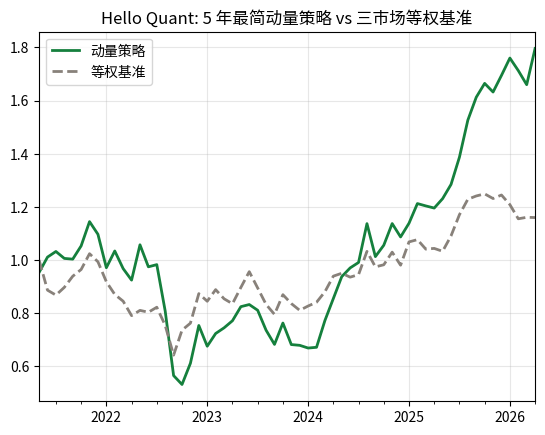

In [8]:
# day_001_hello_quant.py — 用 30 行代码体验量化的'数据→模型→评估'三件套(中国版)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 数据层:同时拉 A 股 / 港股 / 美股 5 年日线(后端 akshare,中国零 VPN)
tickers = {'茅台': '600519.SS', '腾讯': '0700.HK', '苹果': 'AAPL'}
df = get_close_multi(tickers, period='5y')
df = df.ffill().dropna(how='all')  # 跨市场交易日不齐,前向填充
df = df.dropna()

# 2. 模型层:计算月度动量(过去 20 日累计收益)
ret_20d = df.pct_change(20)
monthly_mom = ret_20d.resample('ME').last()

# 3. 评估层:每月持有动量最强的那只,记录下个月收益
next_month_ret = df.pct_change(20).shift(-20).resample('ME').last()
winners = monthly_mom.dropna().idxmax(axis=1)
rets = []
for date, sym in winners.items():
    if date in next_month_ret.index:
        rets.append(next_month_ret.loc[date, sym])
rets = pd.Series(rets, index=winners.index[:len(rets)]).dropna()

# 4. 对比基准(三只等权)
bench = next_month_ret.mean(axis=1).reindex(rets.index)

ann_strat = (1 + rets).prod() ** (12 / len(rets)) - 1
ann_bench = (1 + bench).prod() ** (12 / len(bench)) - 1
print(f'最简动量策略年化:{ann_strat:.2%}')
print(f'三市场等权基准年化:{ann_bench:.2%}')

(1 + rets).cumprod().plot(label='动量策略', color='#15803d', linewidth=2)
(1 + bench).cumprod().plot(label='等权基准', color='#88817a', linewidth=2, linestyle='--')
plt.title('Hello Quant: 5 年最简动量策略 vs 三市场等权基准')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('day001_hello.png', dpi=120, bbox_inches='tight')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| A 股 | 600519 贵州茅台 | 5 年涨幅约 320%,但中间 2021-2023 最大回撤 50%。验证:好公司 ≠ 好买点,你需要的是策略而不是信仰。 |
| 港股 | 0700 腾讯 | 2021 年高点至今最大回撤 70%,然后 2024 反弹 60%。最适合做配对/反转因子的标的。 |
| 美股 | QQQ 纳斯达克 100 ETF | 10 年年化 ~16%,但 2022 年 -33%。覆盖动量/低波/期权 covered call 三种策略的最佳沙盒。 |
| 加密 | BTC + ETH funding rate | 永续合约 funding 长期为正,做空永续 + 现货对冲,2021-2024 年化 8-15%,Sharpe 长期稳定。散户最容易上手的真实 alpha。 |


## 常见坑

### ⚠ 01. 急于实盘

看了 10 节就想真金白银上场。结果被未学过的坑教育——前视函数、滑点、突发停牌。规则:不跑完 P5 不上实盘。

### ⚠ 02. 盲目追神

不存在 100% 胜率的策略。任何宣称的'稳赚不赔'都是骗局或者样本太短。看到夏普比率 5.0 + 的回测,先怀疑数据。

### ⚠ 03. 看视频不写代码

懂 ≠ 会。每节课至少把代码敲一遍跑通。不写代码学量化等于不游泳学游泳。

### ⚠ 04. 不记笔记

365 节的概念量是巨大的。如果不写一句话笔记,5 个月后你 80% 内容会忘掉。Notion/飞书/Obsidian/纸笔皆可,但必须写。

### ⚠ 05. 孤军奋战

找一个学习伙伴或社区(GitHub Discussions / 雪球量化圈 / 知识星球)。讨论比独学效率高 3 倍。

## 实战 SOP · 学习节奏 SOP

1. 周一到周日:每天 1 节视频(15-30 分钟)+ 1 份 PDF(5-10 分钟)+ 1 份代码(10-30 分钟)
2. 周一/三/五:重头戏,涉及新概念或新代码,留 60 分钟
3. 周二/四/六:消化巩固,30-40 分钟即可
4. 周日:不学新课,把本周 5-6 节在脑里串一遍,补漏 / 写一篇 200 字本周心得
5. 每月最后一天:跑一次月度复盘,把当月 30 节做成知识地图
6. 进度落后的应对:不补,直接跟最新节奏。错过的内容标记下来,在下个月度复盘补

> 把这段打印贴在你电脑边。

## 总结 · 你应该带走的

2. 量化 = 数据 + 模型 + 工程,缺一不可。任何一层薄弱都赚不到钱。
3. 散户量化的窗口是真实的,但不要贪。中低频策略 + 小资金 + 严格风控 = 长期可活。
4. 365 天分 11 阶段:基础 → 工具 → 因子 → 策略 → 回测 → ML → 衍生品 → 风控 → HFT → 实盘 → 前沿。
5. 起步只需要免费工具:Python + Tushare/yfinance + Backtrader。3 个月后再考虑付费。
6. 每天 30-60 分钟 × 365 天 = 真正的复利。1.01^365 ≈ 38 倍,1.00^365 = 1 倍,差距全在'每天'。
7. 5 大坑:急于实盘 / 追神 / 不写代码 / 不记笔记 / 一个人闷头干。提前知道就能避开。
8. 今天就开始的两个动作:装 Python 环境(Anaconda) + 注册一个 GitHub 账号 + 建一个 quant_journal 文件夹。
9. 这不是一节赚钱课,是一节让你判断'要不要赚这个钱'的课。明天起进入真正的内容。

## 自测题

**Q1.** 你能用 30 秒向一个完全不懂的朋友讲清楚'什么是量化交易'吗?
**Q2.** 看完今天的内容,你属于'更想学下去'还是'觉得不适合自己'?后者也是一个有价值的答案。
**Q3.** 你目前最薄弱的一层是什么:数据/数学/Python/资金/时间?第一周该专攻这一层。

把答案写下来,3 天后再回看。

## 下一节预告

**Day 002 · 量化交易 vs 主观交易** (Quant vs Discretionary)

Day 2 我们对比 量化交易 vs 主观交易,看清两者的本质差异、各自的优势和盲区,以及为什么大资金最后基本都走向量化。

## 推荐阅读

- 《Quantitative Trading》Ernest Chan — 散户量化最易读的入门书
- 《Inside the Black Box》Rishi Narang — 量化基金内部到底怎么运作
- 《打开量化投资的黑箱》(中文版) — 上一本的中译,适合中文读者
- 纪录片《The Quants》(2010) — Renaissance / LTCM 故事
- B 站搜索:'量化投资入门' 或 '邢不行量化' — 中文社区入口